## Projectile Motion in 2D $\hspace{10mm} \displaystyle m \frac{d\vec{v}}{dt} = -m g \hat{y} -b v \vec{v}$

$\hspace{70mm} \displaystyle \frac{dv_x}{dt} = - g - \frac{b}{m} v v_x \hspace{10mm} \frac{dv_y}{dt} = - g - \frac{b}{m} v v_y$

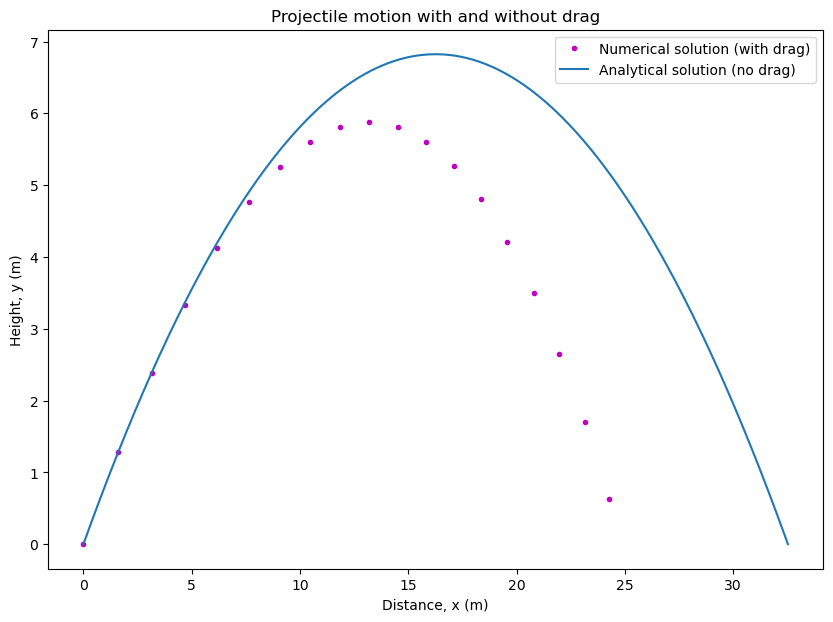

Distance to impact: 24.887 m
Maximum height: 5.878 m
Time of flight: 2.186 s
Velocity at impact: (9.465, -10.085) m/s
Impact speed: 13.831 m/s
Impact angle: -46.815 degrees from horizontal
Range reduction due to drag: 7.639 m


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Physical parameters
b = 0.006      # drag coefficient (kg/m)
g = 9.81       # gravitational acceleration (m/s^2)
m = 0.45       # mass of the ball (kg)
v0 = 18        # initial speed (m/s)
theta_deg = 40 # launch angle (degrees)


# -------------------------------
# System of ODEs with drag
# state = [x, y, vx, vy]
# -------------------------------
def projectile_with_drag(t, state):
    x, y, vx, vy = state

    # magnitude of velocity vector
    speed = np.sqrt(vx**2 + vy**2)

    # equations of motion
    dxdt = vx
    dydt = vy
    dvxdt = -(b/m) * speed * vx
    dvydt = -g - (b/m) * speed * vy

    return [dxdt, dydt, dvxdt, dvydt]


# Event function: stop when y = 0
# (when projectile hits the ground)
def hit_ground(t, state):
    return state[1]  # y-position


# Stop integration when event occurs
hit_ground.terminal = True

# Only trigger when crossing downward
hit_ground.direction = -1


# Analytical solution (no drag)
def no_drag_trajectory(t):
    theta = np.radians(theta_deg)

    x = v0 * np.cos(theta) * t
    y = v0 * np.sin(theta) * t - 0.5 * g * t**2

    return x, y


# Initial conditions
theta = np.radians(theta_deg)

# state = [x0, y0, vx0, vy0]
initial_state = [0, 0, v0 * np.cos(theta), v0 * np.sin(theta)]


# Time range for integration
# Use no-drag flight time as an upper bound
t_flight_no_drag = 2 * v0 * np.sin(theta) / g

# Create time points for evaluation
t_eval = np.linspace(0, t_flight_no_drag, 501)


# -------------------------------
# Solve the system numerically
# -------------------------------
solution = solve_ivp(
    projectile_with_drag,
    (0, t_flight_no_drag),
    initial_state,
    t_eval = t_eval,
    events = hit_ground,
    method = "LSODA"
)


# -------------------------------
# Extract numerical solution
# -------------------------------
t_drag = solution.t
x_drag = solution.y[0]
y_drag = solution.y[1]
vx_drag = solution.y[2]
vy_drag = solution.y[3]


# -------------------------------
# Extract impact information
# -------------------------------
impact_time = solution.t_events[0][0]
impact_state = solution.y_events[0][0]

impact_x = impact_state[0]
impact_y = impact_state[1]
impact_vx = impact_state[2]
impact_vy = impact_state[3]

# magnitude and direction of impact velocity
impact_speed = np.sqrt(impact_vx**2 + impact_vy**2)
impact_angle = np.degrees(np.arctan2(impact_vy, impact_vx))


# Analytical (no-drag) comparison
x_no_drag, y_no_drag = no_drag_trajectory(t_eval)

# final range without drag
range_no_drag = x_no_drag[-1]

# difference due to drag
range_reduction = range_no_drag - impact_x


# Plot trajectories
plt.figure(figsize = (10, 7))

# numerical solution (points evenly spaced in time, 
# distance between them communicates the speed of the projectile)
plt.plot(
    x_drag[::25],
    y_drag[::25],
    "m.",
    label = "Numerical solution (with drag)"
)

# analytical solution (smooth curve)
plt.plot(
    x_no_drag,
    y_no_drag,
    "-",
    label = "Analytical solution (no drag)"
)

plt.xlabel("Distance, x (m)")
plt.ylabel("Height, y (m)")
plt.title("Projectile motion with and without drag")
plt.legend()

plt.show()



# Output results
print(f"Distance to impact: {impact_x:.3f} m")
print(f"Maximum height: {np.max(y_drag):.3f} m")
print(f"Time of flight: {impact_time:.3f} s")
print(f"Velocity at impact: ({impact_vx:.3f}, {impact_vy:.3f}) m/s")
print(f"Impact speed: {impact_speed:.3f} m/s")
print(f"Impact angle: {impact_angle:.3f} degrees from horizontal")
print(f"Range reduction due to drag: {range_reduction:.3f} m")